Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Saved tree image.


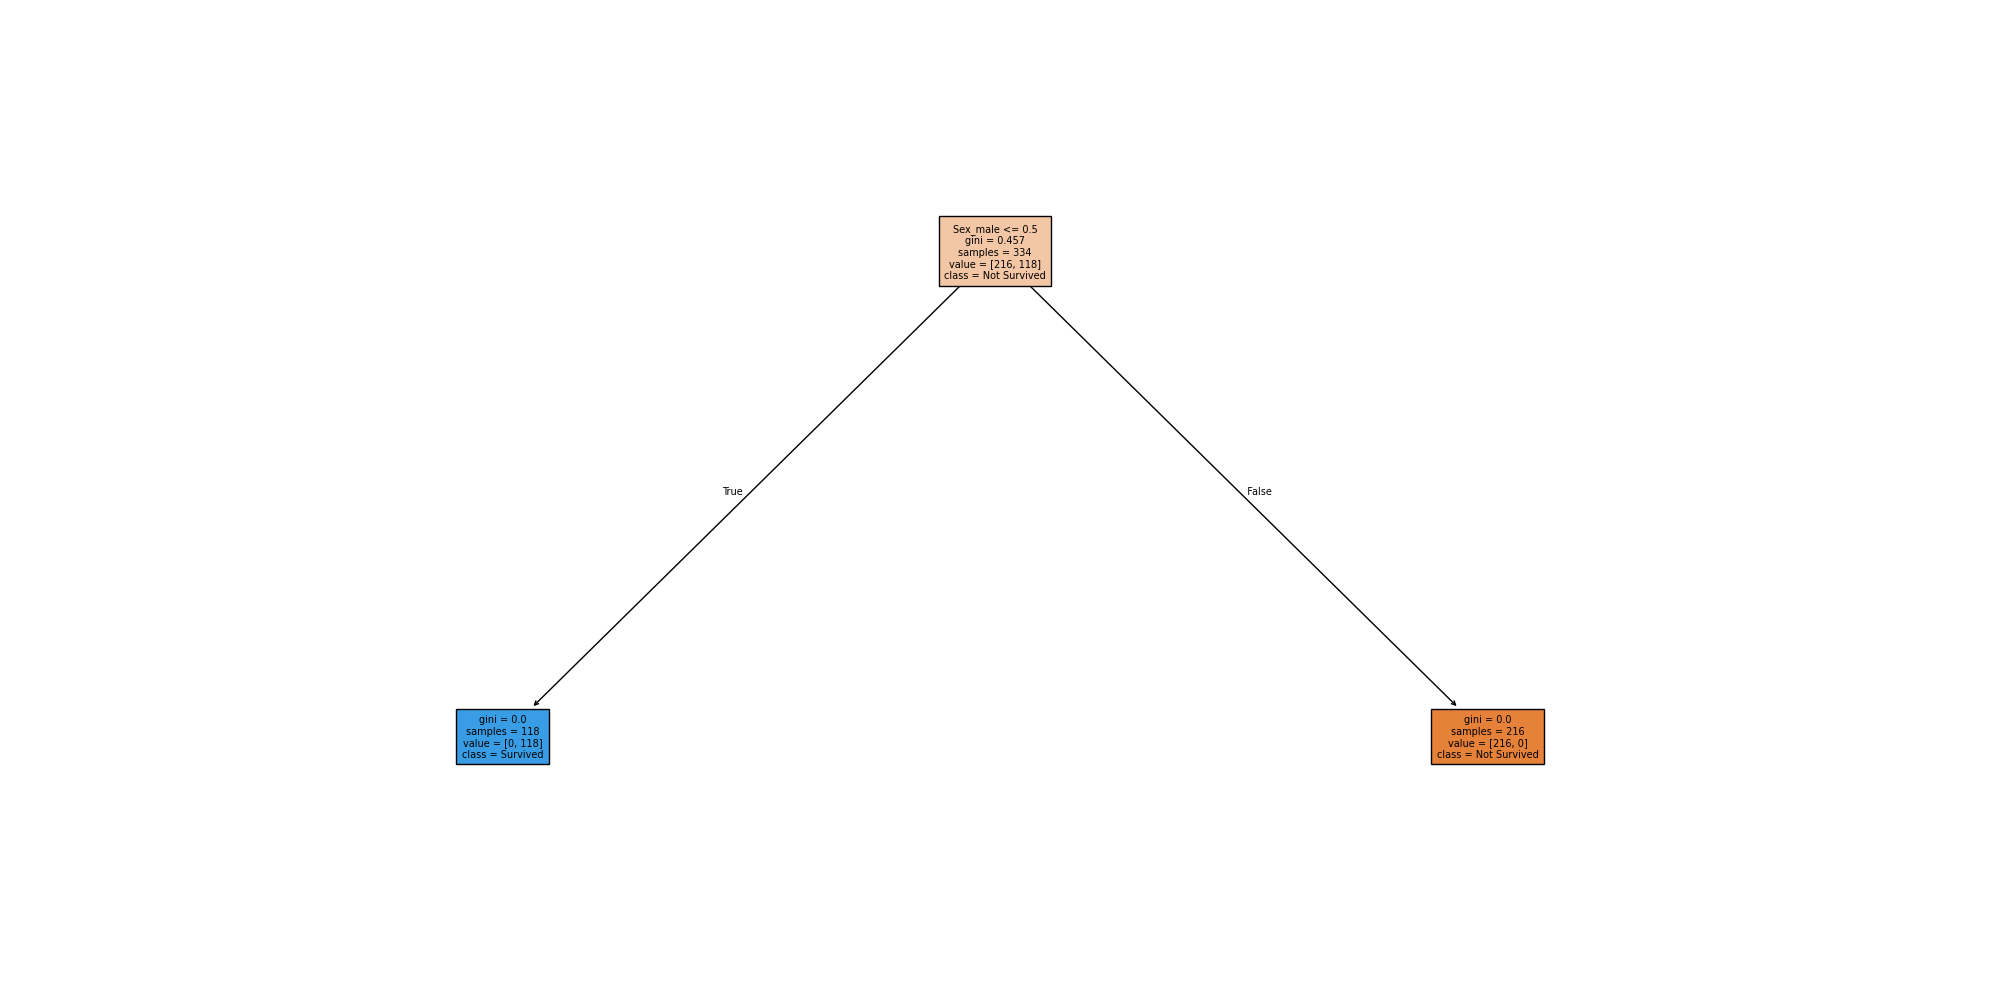

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('/content/tested .csv')
# df = df.drop(columns=['IsAnomaly']) # This line caused the error as 'IsAnomaly' column does not exist in the loaded dataset

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        # Fill non-numeric columns, typically categorical, with their mode
        if col in ['Embarked']:
            df[col] = df[col].fillna(df[col].mode()[0])

# Drop columns not suitable for direct modeling in Titanic dataset
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# Identify categorical columns for one-hot encoding in Titanic dataset
categorical_cols_titanic = ['Sex', 'Pclass', 'Embarked']

df_encoded = pd.get_dummies(df, columns=categorical_cols_titanic, drop_first=True)

# Define X and y for the Titanic dataset
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# 1. Load the simple dataset
# ---------------------------------------------------------------------
df = pd.read_csv('/content/tested .csv') # Corrected filename

# Drop columns not useful for modeling in Titanic dataset
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# Handle missing values - specific to Titanic dataset
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        if col in ['Embarked']:
            df[col] = df[col].fillna(df[col].mode()[0])

# Identify categorical columns for one-hot encoding in Titanic dataset
categorical_cols_titanic = ['Sex', 'Pclass', 'Embarked']
df_encoded = pd.get_dummies(df, columns=categorical_cols_titanic, drop_first=True)


print("Sample of the dataset:")
print(df_encoded.head())
print(f"\nDataset shape: {df_encoded.shape}")

TARGET = "Survived" # Corrected target for Titanic dataset

print(f"Class balance:\n{df_encoded[TARGET].value_counts()}")

feature_names = [c for c in df_encoded.columns if c not in [TARGET]]
X = df_encoded[feature_names].values
y = df_encoded[TARGET].values

# ---------------------------------------------------------------------
# 2. Train / test split
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ---------------------------------------------------------------------
# 3. Train a Random Forest
# ---------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 4. Evaluate
# ---------------------------------------------------------------------
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------------------
# 5. Feature importances
# ---------------------------------------------------------------------
print("Feature importances:")
for name, importance in sorted(
    zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
   Survived   Age  SibSp  Parch     Fare  Sex_male  Pclass_2  Pclass_3  \
0         0  34.5      0      0   7.8292      True     False      True   
1         1  47.0      1      0   7.0000     False     False      True   
2         0  62.0      0      0   9.6875      True      True     False   
3         0  27.0      0      0   8.6625      True     False      True   
4         1  22.0      1      1  12.2875     False     False      True   

   Embarked_Q  Embarked_S  
0        True       False  
1       False        True  
2        True       False  
3       False        True  
4       False        True  

Dataset shape: (418, 10)
Class balance:
Survived
0    266
1    152
Name: count, dtype: int64

OOB score: 1.0000
Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.